## ANN for Regression Problem statement. 

#### Problem statement - Churn_Modelling.csv file has customer details, We need to predict the estimated salary based on ther input field.

In [31]:
#importing all the important packages, lib for this implementation
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import pickle

In [32]:
#accessing the data from .csv file using pandas library 
data=pd.read_csv("Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Preprocessing the data

In [33]:
#Drop the irrelavant column
data=data.drop(['RowNumber','CustomerId','Surname'],axis=1)
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [34]:
#Encode the categorical Variables.

#Creates encoder to convert text → numbers
label_encoder_gender=LabelEncoder()

#Learns unique categories + converts them
#Stores the numeric values back into the column
data['Gender']=label_encoder_gender.fit_transform(data['Gender']) # 
data



,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [35]:
#Onehot encoder 'Geography'
from sklearn.preprocessing import OneHotEncoder
onehot_encoder_geo=OneHotEncoder()

#Two brackets → a table with one column
#OneHotEncoder needs a table, not a list.
geo_encoder=onehot_encoder_geo.fit_transform(data[['Geography']])
geo_encoder

"""Note: A sparse matrix is a matrix that contains mostly zeros.
Instead of storing all the zeros, it only stores the locations of the non-zero values.
This saves huge memory and makes calculations faster.""" 


'Note: A sparse matrix is a matrix that contains mostly zeros.\nInstead of storing all the zeros, it only stores the locations of the non-zero values.\nThis saves huge memory and makes calculations faster.'

In [36]:
onehot_encoder_geo.get_feature_names_out(['Geography'])

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [37]:
#geo_encoder.toarray()- Convert sparse → dense matrix
#get_feature_names_out()- Get names of one-hot columns
#pd.DataFrame(...) - Create a DataFrame from the array

geo_encoder_df=pd.DataFrame(geo_encoder.toarray(),columns=onehot_encoder_geo.get_feature_names_out(['Geography']))
geo_encoder_df

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
9995,1.0,0.0,0.0
9996,1.0,0.0,0.0
9997,1.0,0.0,0.0
9998,0.0,1.0,0.0


In [38]:
##Combine one hot encoder columns with the original data
data=pd.concat([data.drop('Geography',axis=1),geo_encoder_df],axis=1)
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [39]:
#Save the encoders and scalers
#Pickling - It saves (serializes) your trained OneHotEncoder object
#into a file so that you can load it later without retraining


with open('label_encoder_gender.pkl','wb') as file:
    pickle.dump(label_encoder_gender,file)

with open('onehot_encoder_geo.pkl','wb') as file:
    pickle.dump(onehot_encoder_geo,file) 

"""ML models must encode new data in the EXACT same way they encoded the training data. 
-> Training the encoder = learning the rules.
-> Pickle = saving the rules in a notebook.
-> Loading the pickle later = reading the rules from the notebook""" 

'ML models must encode new data in the EXACT same way they encoded the training data. \n-> Training the encoder = learning the rules.\n-> Pickle = saving the rules in a notebook.\n-> Loading the pickle later = reading the rules from the notebook'

In [40]:
#Divide the dataset into independent and dependent features
X=data.drop('EstimatedSalary',axis=1)
y=data['EstimatedSalary']

##Split the data into training and testing sets
#20% of your data → testing 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

##Scale down the features ,Standardization converts everything to the same unit scale 
scaler=StandardScaler()

#fit() - > Learns parameters from training data only ,mean of each column,standard deviation of each column
X_train=scaler.fit_transform(X_train)
# No fit on X_test ,Apply scaling using learned mean & std 
X_test=scaler.transform(X_test) 

X_train

array([[ 0.35649971,  0.91324755, -0.6557859 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [-0.20389777,  0.91324755,  0.29493847, ..., -0.99850112,
         1.72572313, -0.57638802],
       [-0.96147213,  0.91324755, -1.41636539, ..., -0.99850112,
        -0.57946723,  1.73494238],
       ...,
       [ 0.86500853, -1.09499335, -0.08535128, ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.15932282,  0.91324755,  0.3900109 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.47065475,  0.91324755,  1.15059039, ..., -0.99850112,
         1.72572313, -0.57638802]], shape=(8000, 12))

In [41]:
with open('scaler.pkl','wb') as file:
    pickle.dump(scaler,file)


In [ ]:
data

### ANN Model creation

In [42]:
#Importing necessary library for creating ANN models with hidden neuron n/w.
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense # used to create hidden layers
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [ ]:
X_train.shape[1],

In [43]:
# Build our ANN Model 
model=Sequential([
    #Defining as 1D array to get all the inputs from the input file.
    Dense(64,activation='relu',input_shape=(X_train.shape[1],)), ## HL1 connected with input layer
    Dense(32,activation='relu'), #HL2 
    Dense(1) # output layer , default activation function returns the actual value
]
)

#64 = number of neurons , Enough capacity to learn patterns ,Common default for starting models 
#activation='relu' - Fast,No vanishing gradient,Works extremely well for deep networks
#input_shape=(X_train.shape[1],) - The input has N features, where N = number of columns in your dataset
#Sigmoid - The sigmoid function converts the final neural network value into a number between 0 and 1, which is interpreted as a probability.
# 0.87 → > 0.5 → Predict 1 (will churn) ,0.12 → < 0.5 → Predict 0 (won’t churn)

d:\AI\KrishNaik_Academy\Coding\NLP\ANN\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

In [44]:
import tensorflow
opt=tensorflow.keras.optimizers.Adam(learning_rate=0.01)
loss=tensorflow.keras.losses.BinaryCrossentropy()

-> model.compile() tells the neural network 1) How to update weights → optimizer 2) How to measure errors → loss function 3) What performance metric to show → metrics 
-> Optimizer controls how fast and how smartly training happens.
-> Adam = Adaptive Moment Estimation - Works well for most datasets ,Fast convergence,Very good for ANN/CNN/RNN 
-> Adamax- Sparse gradients	- Stable alternative to Adam
-> Nadam -Combines Adam + Nesterov - Faster convergence 

-> Loss tells the network how wrong it is.Backpropagation uses loss to adjust weights.
-> For binary classification (0/1), the BEST loss is: Binary Cross-Entropy ,This loss punishes confident wrong predictions very strongly, which improves learning. 


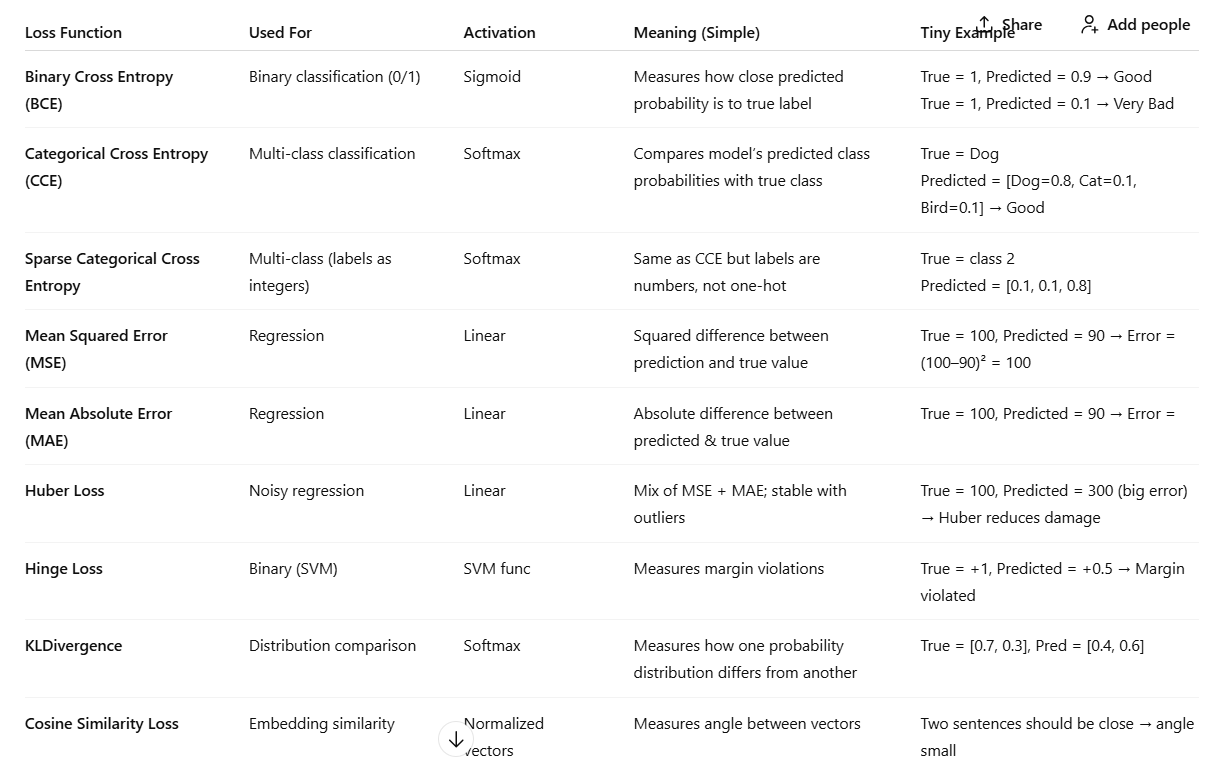

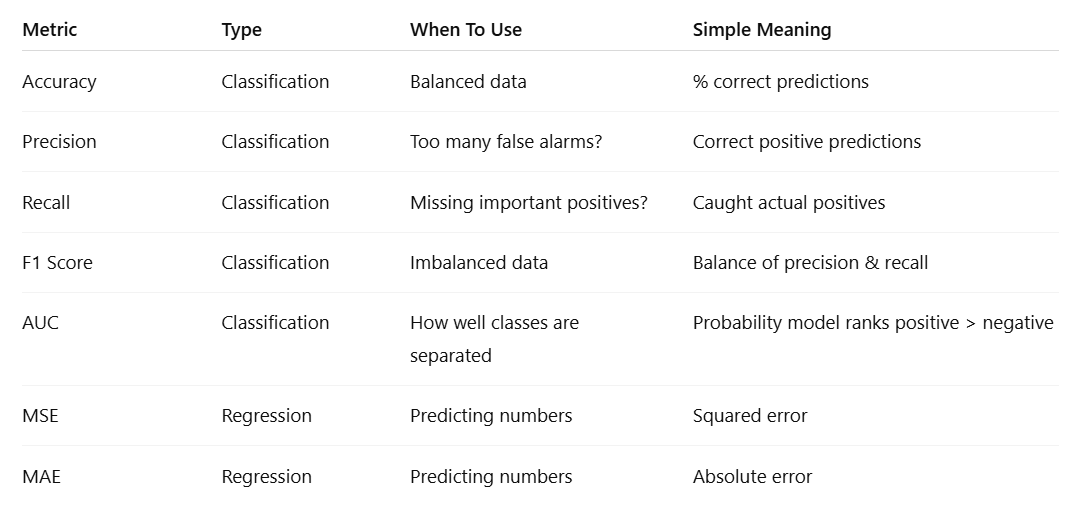

In [45]:
#Compile the model
model.compile(optimizer=opt,loss='mean_absolute_error',metrics=['mae'])

In [46]:
#Setup the tensor board 
#TensorBoard is a visual dashboard for deep learning-  Is the model learning correctly?
#Is it overfitting? Is learning rate right? When to stop training? 
 
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard

#Folder to store logs 
log_dir="logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")  #logs/fit20250127-153210

#Enables TensorBoard during training 
# Every epoch, write training metrics to the log directory so TensorBoard can display them
tensorflow_callback=TensorBoard(log_dir,histogram_freq=1)


In [47]:
#Setup up call Early stopping 
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

#monitor='val_loss' - So model stops when val_loss stops improving. 
#patience=5 - 5 is a common good choice 
#Save the model weights from the epoch with best val_loss ,At the end of training, revert back to those best weights

In [ ]:
"""fit() trains your neural network.
It performs: 
Forward pass → makes predictions
Loss calculation → how wrong the model is
Backpropagation → calculates gradients
Weight update → optimizer adjusts weights
Repeats for all epochs"""

In [48]:
# Train the model
history=model.fit(
    X_train,y_train,validation_data=(X_test,y_test),epochs=100,
    callbacks=[tensorflow_callback,early_stopping_callback]
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 79871.0391 - mae: 79871.0391 - val_loss: 51444.7812 - val_mae: 51444.7812
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 50433.1055 - mae: 50433.1055 - val_loss: 50600.5469 - val_mae: 50600.5469
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 50008.5430 - mae: 50008.5430 - val_loss: 50536.1367 - val_mae: 50536.1367
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 49828.0742 - mae: 49828.0742 - val_loss: 50286.4297 - val_mae: 50286.4297
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 49696.8359 - mae: 49696.8359 - val_loss: 50358.2031 - val_mae: 50358.2031
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 49623.4844 - mae: 49623.4844 - val_loss: 50260.7266 - val_mae: 50260.7266
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 49579.3945 - mae: 49579.3945 - val_loss: 50282.8945 - val_mae: 50282.8945
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - 

In [ ]:
"""validation_data - “After each epoch, test the model on the test set
-> BUT due to EarlyStopping, the model will NOT always run 100 epochs.
-> Callbacks are special tools that modify training behavior.
-> tensorflow_callback - This writes logs for TensorBoard 
-> early_stopping_callback - Stops training automatically when the model stops improving."""

In [ ]:
#Load tensorboard extension 
%load_ext tensorboard

In [ ]:
!pip install tensorboard
!pip install tensorboard-plugin-profile

In [ ]:
%tensorboard --logdir logs/fit

In [49]:
#evalute model on the test data
test_loss,test_mae=model.evaluate(X_test,y_test)
print(f'Test MAE : {test_mae}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 50229.6875 - mae: 50229.6875
Test MAE : 50229.6875


In [ ]:
#To save the trained model
model.save('regression_model.h5')

In [53]:
import streamlit as st
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
import pandas as pd
import pickle
from pathlib import Path

# Get the directory where this script lives
BASE_DIR = Path().resolve().parent

# Load the trained model
model = tf.keras.models.load_model('regression_model.h5')

# Load the encoders and scaler
label_encoder_gender_path = BASE_DIR / "label_encoder_gender.pkl"
onehot_encoder_geo_path = BASE_DIR / "onehot_encoder_geo.pkl"
scaler_path = BASE_DIR / "scaler.pkl"

# Load the encoders and scaler
with open('label_encoder_gender.pkl','rb') as file:
    label_encoder_gender=pickle.load(file)

with open('onehot_encoder_geo.pkl','rb') as file:
    onehot_encoder_geo=pickle.load(file) 

with open('scaler.pkl','rb') as file:
    scaler=pickle.load(file)


## streamlit app
st.title('Estimated Salary Prediction')

# User input
geography = st.selectbox('Geography', onehot_encoder_geo.categories_[0])
gender = st.selectbox('Gender',label_encoder_gender.classes_)
age = st.slider('Age', 18, 92)
balance = st.number_input('Balance')
credit_score = st.number_input('Credit Score')
estimated_salary = st.number_input('Estimated Salary')
tenure = st.slider('Tenure', 0, 10)
num_of_products = st.slider('Number of Products', 1, 4)
has_cr_card = st.selectbox('Has Credit Card', [0, 1])
is_active_member = st.selectbox('Is Active Member', [0, 1])

# Prepare the input data
input_data = pd.DataFrame({
    'CreditScore': [credit_score],
    'Gender': [label_encoder_gender.transform([gender])[0]],
    'Age': [age],
    'Tenure': [tenure],
    'Balance': [balance],
    'NumOfProducts': [num_of_products],
    'HasCrCard': [has_cr_card],
    'IsActiveMember': [is_active_member],
    'EstimatedSalary': [estimated_salary]
})
# The OneHotEncoder expects a 2D array, so we wrap the selected geography inside [[ ]].
# This converts a category like "France" into a one-hot vector such as [1, 0, 0].
# .toarray() ensures we get a dense NumPy array instead of a sparse matrix.

# One-hot encode 'Geography'
geo_encoded = onehot_encoder_geo.transform([[geography]]).toarray()

# Convert the encoded array into a DataFrame with proper column names.
# get_feature_names_out(['Geography']) generates columns like:
# ['Geography_France', 'Geography_Germany', 'Geography_Spain'] 

geo_encoded_df = pd.DataFrame(geo_encoded, columns=onehot_encoder_geo.get_feature_names_out(['Geography']))

# -------------------------------
# 2. Combine encoded geography with other input features
# -------------------------------
# input_data contains all the numerical and label-encoded features.
# geo_encoded_df contains the one-hot encoded geography columns.
# We merge them side-by-side (axis=1).
# reset_index(drop=True) ensures indexes align correctly (both start at 0).

input_data = pd.concat([input_data.reset_index(drop=True), geo_encoded_df], axis=1)

# -------------------------------
# 3. Scale the combined input data
# -------------------------------
# The StandardScaler applies the SAME scaling used during model training.
# This ensures the values (age, balance, salary, etc.) match the distribution
# the neural network was trained on, avoiding distorted predictions.
# Scale the input data

input_data_scaled = scaler.transform(input_data)

# -------------------------------
# 4. Make prediction using the trained model
# -------------------------------
# The neural network expects the scaled input features.
# model.predict() returns a NumPy array of predictions.
# For a single row of input, the output looks like: [[value]]
# So we extract the first element using prediction[0][0]

prediction = model.predict(input_data_scaled)
prediction_salary = prediction[0][0]

# -------------------------------
# 5. Display the prediction in Streamlit
# -------------------------------
# We format the value to two decimal places.
# The message can be customized depending on how you want to present the result.
st.write(f'Predicted Estimated Salary: ${prediction_salary:.2f}')



2025-11-28 05:17:21.486 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-28 05:17:21.604 
  command:

    streamlit run d:\AI\KrishNaik_Academy\Coding\NLP\ANN\venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-11-28 05:17:21.605 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-28 05:17:21.606 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-28 05:17:21.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-28 05:17:21.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-28 05:17:21.610 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-28 05:17:21.612 Thre

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- EstimatedSalary
Feature names seen at fit time, yet now missing:
- Exited
